In [2]:
# CELL 1 — Setup
install.packages(c("dplyr", "ggplot2", "broom"), quiet = TRUE)

library(dplyr)
library(ggplot2)
library(broom)

df <- read.csv("patient_adherence.csv")
str(df)

'data.frame':	5000 obs. of  12 variables:
 $ patient_id     : chr  "PT00000" "PT00001" "PT00002" "PT00003" ...
 $ age            : int  70 64 52 70 45 54 47 66 74 61 ...
 $ region         : chr  "Northeast" "West" "West" "Southeast" ...
 $ drug_class     : chr  "Antihypertensives" "Antidiabetics" "Statins" "Statins" ...
 $ prescriber_id  : chr  "PR0024" "PR0131" "PR0178" "PR0138" ...
 $ copay_tier     : chr  "Medium" "Medium" "Low" "Medium" ...
 $ n_comorbidities: int  1 2 1 2 0 1 3 1 3 1 ...
 $ mail_order     : int  1 0 0 0 0 0 0 1 1 0 ...
 $ new_to_therapy : int  0 1 0 1 0 0 1 0 0 1 ...
 $ pdc            : num  0.743 0.502 0.627 0.231 0.818 0.924 0.574 0.698 0.793 0.6 ...
 $ non_adherent   : int  1 1 1 1 0 0 1 1 1 1 ...
 $ risk_cohort    : chr  "Low Risk" "High Risk" "Medium Risk" "High Risk" ...


In [3]:
# CELL 2 — Recreate risk_cohort and prep factors (mirrors the Python notebook)
df$copay_tier <- factor(df$copay_tier, levels = c("Low", "Medium", "High"))
df$drug_class <- factor(df$drug_class)
df$region <- factor(df$region)

summary(df)

     patient_id        age              region                 drug_class  
 Length   :5000   Min.   :21.00   Midwest  :1022   Anticoagulants   : 717  
 N.unique :5000   1st Qu.:48.00   Northeast:1130   Antidiabetics    :1064  
 N.blank  :   0   Median :58.00   Southeast: 849   Antihypertensives:1477  
 Min.nchar:   7   Mean   :57.82   Southwest:1228   Statins          :1742  
 Max.nchar:   7   3rd Qu.:67.00   West     : 771                           
                  Max.   :90.00                                            
   prescriber_id   copay_tier   n_comorbidities   mail_order    
 Length   :5000   Low   :1922   Min.   :0.000   Min.   :0.0000  
 N.unique : 250   Medium:2076   1st Qu.:1.000   1st Qu.:0.0000  
 N.blank  :   0   High  :1002   Median :1.000   Median :0.0000  
 Min.nchar:   6                 Mean   :1.515   Mean   :0.2894  
 Max.nchar:   6                 3rd Qu.:2.000   3rd Qu.:1.0000  
                                Max.   :8.000   Max.   :1.0000  
 new_to_thera

In [4]:
# CELL 3 — Exploratory analysis (same cuts as the Python version)
cat("Overall non-adherence rate:", round(mean(df$non_adherent), 3), "\n\n")

cat("By copay tier:\n")
print(df %>% group_by(copay_tier) %>% summarise(non_adherent_rate = round(mean(non_adherent), 3)))

cat("\nBy drug class:\n")
print(df %>% group_by(drug_class) %>% summarise(non_adherent_rate = round(mean(non_adherent), 3)))

cat("\nNew-to-therapy vs existing:\n")
print(df %>% group_by(new_to_therapy) %>% summarise(non_adherent_rate = round(mean(non_adherent), 3)))

Overall non-adherence rate: 0.79 

By copay tier:
# A tibble: 3 × 2
  copay_tier non_adherent_rate
  <fct>                  <dbl>
1 Low                    0.682
2 Medium                 0.814
3 High                   0.947

By drug class:
# A tibble: 4 × 2
  drug_class        non_adherent_rate
  <fct>                         <dbl>
1 Anticoagulants                0.774
2 Antidiabetics                 0.785
3 Antihypertensives             0.779
4 Statins                       0.809

New-to-therapy vs existing:
# A tibble: 2 × 2
  new_to_therapy non_adherent_rate
           <int>             <dbl>
1              0             0.707
2              1             0.916


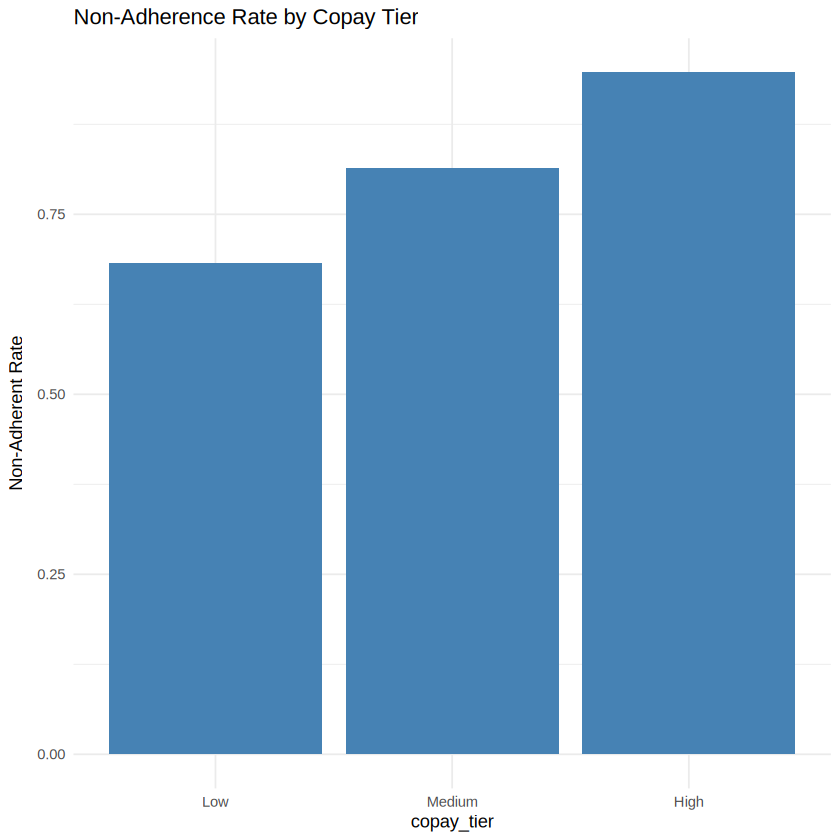

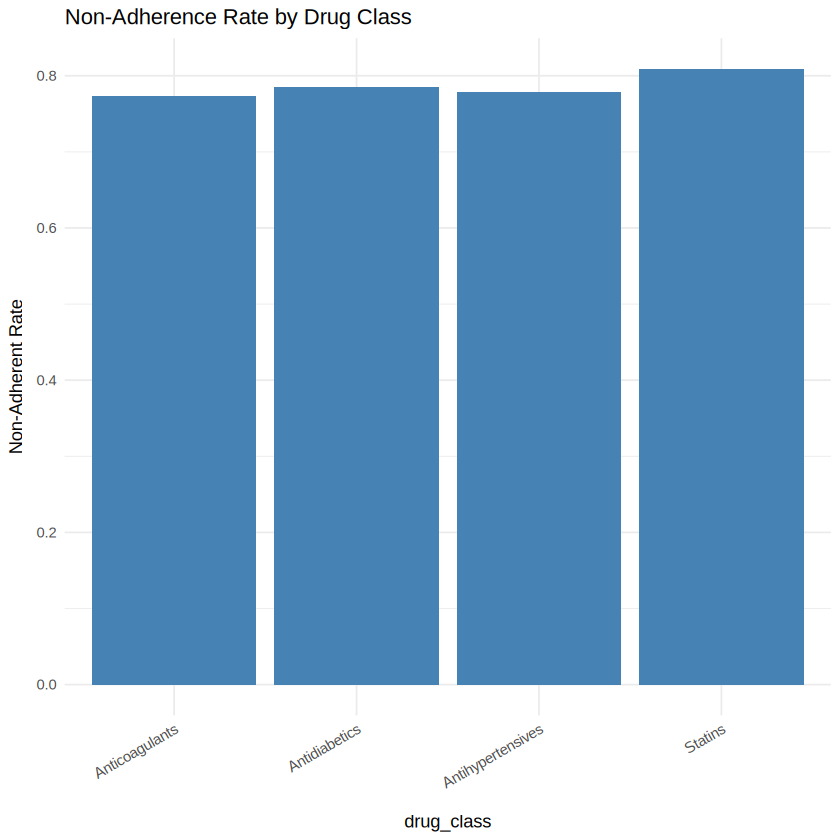

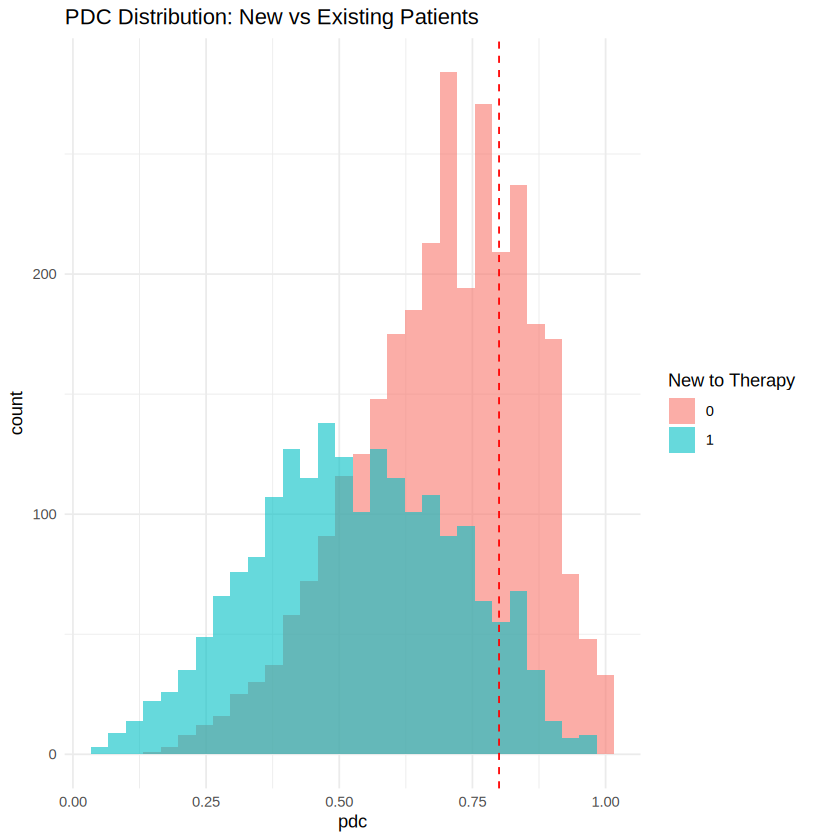

In [5]:
# CELL 4 — Visualization (ggplot2 equivalent of the seaborn plots)
p1 <- ggplot(df, aes(x = copay_tier, y = non_adherent)) +
  stat_summary(fun = mean, geom = "bar", fill = "steelblue") +
  labs(title = "Non-Adherence Rate by Copay Tier", y = "Non-Adherent Rate") +
  theme_minimal()

p2 <- ggplot(df, aes(x = drug_class, y = non_adherent)) +
  stat_summary(fun = mean, geom = "bar", fill = "steelblue") +
  labs(title = "Non-Adherence Rate by Drug Class", y = "Non-Adherent Rate") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

p3 <- ggplot(df, aes(x = pdc, fill = factor(new_to_therapy))) +
  geom_histogram(alpha = 0.6, bins = 30, position = "identity") +
  geom_vline(xintercept = 0.80, linetype = "dashed", color = "red") +
  labs(title = "PDC Distribution: New vs Existing Patients", fill = "New to Therapy") +
  theme_minimal()

print(p1)
print(p2)
print(p3)

ggsave("adherence_eda_R.png", p3, width = 8, height = 5, dpi = 150)

In [6]:
# CELL 5 — Logistic regression: predicting non-adherence (glm, same formula as statsmodels)
model_df <- df %>%
  mutate(
    copay_medium = as.integer(copay_tier == "Medium"),
    copay_high = as.integer(copay_tier == "High")
  )

logit_model <- glm(
  non_adherent ~ age + copay_medium + copay_high + mail_order + n_comorbidities + new_to_therapy,
  data = model_df,
  family = binomial(link = "logit")
)

summary(logit_model)


Call:
glm(formula = non_adherent ~ age + copay_medium + copay_high + 
    mail_order + n_comorbidities + new_to_therapy, family = binomial(link = "logit"), 
    data = model_df)

Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)      2.170628   0.193788   11.20   <2e-16 ***
age             -0.039679   0.003049  -13.01   <2e-16 ***
copay_medium     0.882443   0.085960   10.27   <2e-16 ***
copay_high       2.625527   0.163437   16.06   <2e-16 ***
mail_order      -1.413658   0.087276  -16.20   <2e-16 ***
n_comorbidities  0.553321   0.039521   14.00   <2e-16 ***
new_to_therapy   1.975114   0.102821   19.21   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 5139.6  on 4999  degrees of freedom
Residual deviance: 3804.9  on 4993  degrees of freedom
AIC: 3818.9

Number of Fisher Scoring iterations: 6


In [7]:
# CELL 6 — Odds ratios with confidence intervals (tidy output via broom)
or_table <- tidy(logit_model, conf.int = TRUE, exponentiate = TRUE) %>%
  select(term, odds_ratio = estimate, OR_low = conf.low, OR_high = conf.high, p.value) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

print(or_table)

# A tibble: 7 × 5
  term            odds_ratio OR_low OR_high p.value
  <chr>                <dbl>  <dbl>   <dbl>   <dbl>
1 (Intercept)          8.76   6.01   12.8         0
2 age                  0.961  0.955   0.967       0
3 copay_medium         2.42   2.04    2.86        0
4 copay_high          13.8   10.1    19.2         0
5 mail_order           0.243  0.205   0.288       0
6 n_comorbidities      1.74   1.61    1.88        0
7 new_to_therapy       7.21   5.91    8.84        0


In [8]:
# CELL 7 — Cohort analysis (region x risk cohort) — same logic as Python
risk_cohort <- function(copay_tier, new_to_therapy, n_comorbidities, mail_order) {
  score <- 0
  if (copay_tier == "High") score <- score + 1
  if (new_to_therapy == 1) score <- score + 1
  if (n_comorbidities >= 2) score <- score + 1
  if (mail_order == 0) score <- score + 1
  if (score >= 3) return("High Risk")
  if (score >= 1) return("Medium Risk")
  return("Low Risk")
}

df$risk_cohort <- mapply(risk_cohort, df$copay_tier, df$new_to_therapy, df$n_comorbidities, df$mail_order)

cohort_summary_r <- df %>%
  group_by(region, risk_cohort) %>%
  summarise(
    patients = n(),
    avg_pdc = round(mean(pdc), 3),
    non_adherent_rate = round(mean(non_adherent), 3),
    .groups = "drop"
  ) %>%
  arrange(region, risk_cohort)

print(cohort_summary_r)

# A tibble: 15 × 5
   region    risk_cohort patients avg_pdc non_adherent_rate
   <fct>     <chr>          <int>   <dbl>             <dbl>
 1 Midwest   High Risk        206   0.444             0.981
 2 Midwest   Low Risk          63   0.836             0.317
 3 Midwest   Medium Risk      753   0.657             0.797
 4 Northeast High Risk        226   0.438             0.991
 5 Northeast Low Risk          69   0.814             0.406
 6 Northeast Medium Risk      835   0.658             0.777
 7 Southeast High Risk        165   0.437             0.982
 8 Southeast Low Risk          49   0.841             0.347
 9 Southeast Medium Risk      635   0.665             0.756
10 Southwest High Risk        243   0.45              0.967
11 Southwest Low Risk         111   0.82              0.369
12 Southwest Medium Risk      874   0.67              0.788
13 West      High Risk        151   0.423             0.993
14 West      Low Risk          61   0.797             0.443
15 West      Medium R

In [9]:
# CELL 8 — Export
write.csv(or_table, "logistic_regression_odds_ratios_R.csv", row.names = FALSE)
write.csv(cohort_summary_r, "cohort_summary_R.csv", row.names = FALSE)
cat("Exported R outputs. Download from the Files panel and add to your repo under /r/.\n")

Exported R outputs. Download from the Files panel and add to your repo under /r/.
